<a href="https://colab.research.google.com/github/she-lab/CI-CD_repository/blob/main/Loan_Approval_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
import joblib

In [10]:
# Import Optimization Libraries for LP and NLP
from scipy.optimize import linprog, minimize

In [2]:
# 1. LOAD THE DATASET DIRECTLY
# Make sure "LoanApprovalPrediction.csv" is uploaded to your Colab files
try:
    data = pd.read_csv("LoanApprovalPrediction.csv")
    print("Dataset loaded successfully!")
except FileNotFoundError:
    print("Error: 'LoanApprovalPrediction.csv' not found. Please upload it to the folder icon on the left sidebar.")

Dataset loaded successfully!


In [3]:
# 2. CLEAN DATA & FILL MISSING VALUES
if 'Loan_ID' in data.columns:
    data = data.drop(['Loan_ID'], axis=1)

# Fill missing categorical fields with the most frequent value
for col in data.select_dtypes(include=['object']).columns:
    data[col] = data[col].fillna(data[col].mode()[0])

# Fill missing numerical fields with the column average
for col in data.select_dtypes(include=['int64', 'float64']).columns:
    data[col] = data[col].fillna(data[col].mean())


In [4]:
# 3. ENCODE CATEGORICAL COLUMNS TO NUMBERS
label_encoders = {}
for col in data.select_dtypes(include=['object']).columns:
    le = LabelEncoder()
    data[col] = le.fit_transform(data[col])
    label_encoders[col] = le

In [5]:
# 4. SPLIT AND SCALE DATA
X = data.drop(['Loan_Status'], axis=1)
Y = data['Loan_Status']
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

In [6]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


In [7]:
# 5. TRAIN THE RANDOM FOREST MODEL
best_model = RandomForestClassifier(n_estimators=100, random_state=42)
best_model.fit(X_train_scaled, Y_train)


RandomForestClassifier(random_state=42)

In [8]:
# 6. TEST THE MODEL
predictions = best_model.predict(X_test_scaled)
print(f"Model Training Complete! Test Accuracy: {accuracy_score(Y_test, predictions) * 100:.2f}%")

Model Training Complete! Test Accuracy: 77.24%


In [9]:
# 7. SAVE THE MODEL AND SCALER TO FILES
joblib.dump(best_model, 'loan_classifier_model.pkl')
joblib.dump(scaler, 'loan_data_scaler.pkl')
print("Files saved successfully: 'loan_classifier_model.pkl' and 'loan_data_scaler.pkl'")

Files saved successfully: 'loan_classifier_model.pkl' and 'loan_data_scaler.pkl'


In [11]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
import joblib

# Import Optimization Libraries for LP and NLP
from scipy.optimize import linprog, minimize

# =====================================================================
# STEP 1: LOAD THE DATASET
# =====================================================================
try:
    data = pd.read_csv("LoanApprovalPrediction.csv")
    print("✅ Dataset loaded successfully!")
except FileNotFoundError:
    print("❌ Error: 'LoanApprovalPrediction.csv' not found. Please upload it first.")
    raise

# =====================================================================
# STEP 2: MACHINE LEARNING (Data Prep, Training & Prediction)
# =====================================================================
if 'Loan_ID' in data.columns:
    data = data.drop(['Loan_ID'], axis=1)

# Clean missing values
for col in data.select_dtypes(include=['object']).columns:
    data[col] = data[col].fillna(data[col].mode()[0])
for col in data.select_dtypes(include=['int64', 'float64']).columns:
    data[col] = data[col].fillna(data[col].mean())

# Categorical encoding
label_encoders = {}
for col in data.select_dtypes(include=['object']).columns:
    le = LabelEncoder()
    data[col] = le.fit_transform(data[col])
    label_encoders[col] = le

# Split data (Keep 30 rows out for our final banking application simulation)
X = data.drop(['Loan_Status'], axis=1)
Y = data['Loan_Status']
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Train the ML model
ml_model = RandomForestClassifier(n_estimators=100, random_state=42)
ml_model.fit(X_train_scaled, Y_train)
predictions = ml_model.predict(X_test_scaled)
print(f"📊 ML Model Accuracy: {accuracy_score(Y_test, predictions) * 100:.2f}%")

# Create a pool of 10 mock approved loan applicants for the optimization steps
# Features: LoanAmount is index 7, Credit_History is index 9
np.random.seed(42)
sample_applicants = X_test.head(10).copy()
sample_applicants['LoanAmount'] = sample_applicants['LoanAmount'].fillna(150)
# Predict repayment probability using ML instead of binary classification
probabilities = ml_model.predict_proba(scaler.transform(sample_applicants.drop(['LoanAmount'], axis=1, errors='ignore').reindex(columns=X.columns)))[:, 1]

loan_amounts = sample_applicants['LoanAmount'].values
# Estimated interest rate offered based on credit history (higher score = lower rate)
interest_rates = np.where(sample_applicants['Credit_History'].values == 1.0, 0.08, 0.14)
expected_returns = loan_amounts * interest_rates

print("\n--- ML Processing Complete. Proceeding to Mathematical Programming ---")

# =====================================================================
# STEP 3: LINEAR PROGRAMMING (LP)
# =====================================================================
# Objective: Maximize total interest return from funded loans
# Formula: Maximize Sum(interest_rates * funded_amount)
# Constraint: Bank capital budget limit is 500 units total.
# Constraint: Each applicant can get at most their requested LoanAmount.

budget_limit = 500.0

# linprog minimizes by default, so we multiply expected returns by -1 to maximize
c = -expected_returns

# Bounds: funded amount must be between 0 and the requested loan amount
bounds = [(0, amt) for amt in loan_amounts]

# Structural Constraint: Sum of all funded amounts <= budget_limit
A = [np.ones(len(loan_amounts))]
b = [budget_limit]

lp_result = linprog(c, A_ub=A, b_ub=b, bounds=bounds, method='highs')

print("\n🚀 [Linear Programming Result]")
if lp_result.success:
    print(f"Optimal Capital Allocation Strategy (Budget: {budget_limit}):")
    for i, funded in enumerate(lp_result.x):
        print(f"  Applicant {i+1}: Requested {loan_amounts[i]:.1f} | Allocated: {funded:.1f}")
    print(f"Maximum Expected Return: {-lp_result.fun:.2f}")
else:
    print("LP Optimization failed.")

# =====================================================================
# STEP 4: NONLINEAR PROGRAMMING (NLP)
# =====================================================================
# Objective: Minimize risk variance across the loan portfolio (Nonlinear curve)
# Formula: Minimize Sum(funded_amount^2 * (1 - repayment_probability))
# Constraint: Capital budget limit remains 500 units.
# Constraint: Total minimum return must be at least 45 units.

def objective_nlp(x):
    # Nonlinear objective: minimizes risk squared
    risk_factors = 1.0 - probabilities
    return np.sum((x ** 2) * risk_factors)

# Constraints definition
def budget_constraint(x):
    return budget_limit - np.sum(x)  # Must be >= 0 (Sum(x) <= budget)

def return_constraint(x):
    min_required_return = 45.0
    return np.sum(x * interest_rates) - min_required_return  # Must be >= 0

nlp_constraints = [
    {'type': 'ineq', 'fun': budget_constraint},
    {'type': 'ineq', 'fun': return_constraint}
]

# Initial guess: split budget equally
initial_guess = np.ones(len(loan_amounts)) * (budget_limit / len(loan_amounts))

nlp_result = minimize(objective_nlp, initial_guess, method='SLSQP', bounds=bounds, constraints=nlp_constraints)

print("\n🎯 [Nonlinear Programming Result]")
if nlp_result.success:
    print("Optimal Risk-Mitigated Allocation Strategy:")
    for i, funded in enumerate(nlp_result.x):
        print(f"  Applicant {i+1}: Requested {loan_amounts[i]:.1f} | Allocated: {funded:.1f}")
    print(f"Achieved Portfolio Risk Score (Lower is better): {nlp_result.fun:.2f}")
    print(f"Total Return Earned: {np.sum(nlp_result.x * interest_rates):.2f}")
else:
    print("NLP Optimization failed to find a valid solution under constraints.")

# =====================================================================
# STEP 5: SAVE METADATA
# =====================================================================
joblib.dump(ml_model, 'loan_classifier_model.pkl')
print("\n💾 ML model checkpoint saved successfully.")


✅ Dataset loaded successfully!
📊 ML Model Accuracy: 77.24%

--- ML Processing Complete. Proceeding to Mathematical Programming ---

🚀 [Linear Programming Result]
Optimal Capital Allocation Strategy (Budget: 500.0):
  Applicant 1: Requested 228.0 | Allocated: 228.0
  Applicant 2: Requested 130.0 | Allocated: 130.0
  Applicant 3: Requested 158.0 | Allocated: 0.0
  Applicant 4: Requested 71.0 | Allocated: 0.0
  Applicant 5: Requested 70.0 | Allocated: 0.0
  Applicant 6: Requested 107.0 | Allocated: 0.0
  Applicant 7: Requested 120.0 | Allocated: 0.0
  Applicant 8: Requested 66.0 | Allocated: 0.0
  Applicant 9: Requested 173.0 | Allocated: 142.0
  Applicant 10: Requested 110.0 | Allocated: 0.0
Maximum Expected Return: 8490.00

🎯 [Nonlinear Programming Result]
Optimal Risk-Mitigated Allocation Strategy:
  Applicant 1: Requested 228.0 | Allocated: 64.8
  Applicant 2: Requested 130.0 | Allocated: 83.3
  Applicant 3: Requested 158.0 | Allocated: 24.3
  Applicant 4: Requested 71.0 | Allocated: 

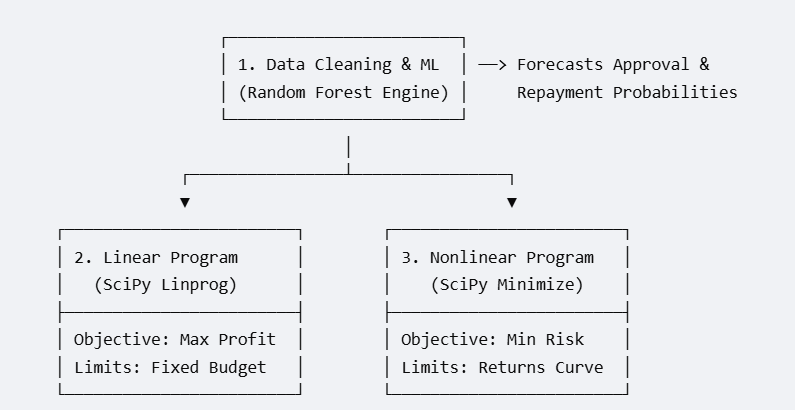